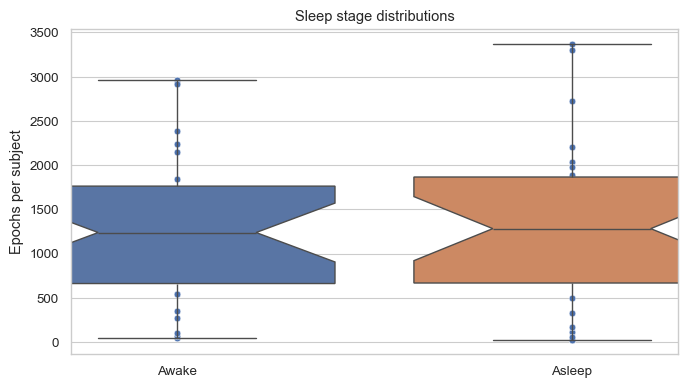

In [10]:
import seaborn as sns 
from pathlib import Path
from matplotlib import pyplot as plt

from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

dataset = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean-with-fd-clamped",
)

RENAME_STAGES = {"W": "Awake", "1": "NREM1", "2": "NREM2", "S": "Asleep"}

df = dataset.events

stage_cols = ["W", "S"]
df[stage_cols] = df[stage_cols].astype(bool)

# (Optional) keep only sleep task rows

# Per-subject count
prop_subj = (
    df
    .groupby(["subject", "run"], as_index=False)[stage_cols]
    .sum()
)

# 
prop_subj = prop_subj.drop(columns="run")
prop_subj = prop_subj.groupby("subject", as_index=False).sum()
prop_subj = prop_subj.rename(columns=RENAME_STAGES)
# prop_subj
# 
# # Wide -> long for seaborn
long = prop_subj.melt(id_vars="subject", var_name="Stage", value_name="Count")
# long["Count"] = long["Count"] * 14.28571429
# 
# # Plot
plt.figure(figsize=(7,4))
sns.boxplot(data=long, x="Stage", y="Count", hue="Stage", notch=True)
sns.scatterplot(data=long, x="Stage", y="Count")
# plt.ylim(0, None)
plt.ylabel("Epochs per subject")
plt.xlabel("")
plt.title("Sleep stage distributions")
plt.tight_layout()
plt.show()

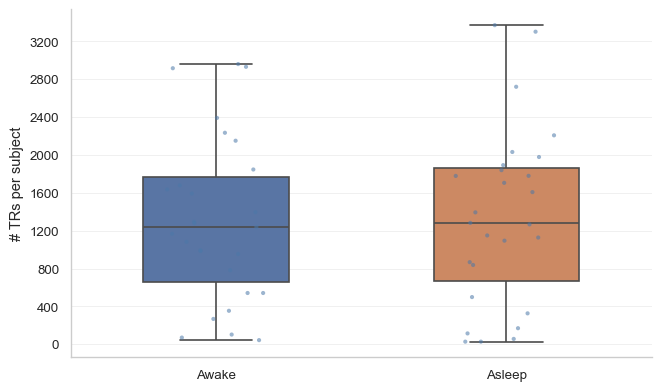

In [12]:
from matplotlib.ticker import MaxNLocator
import seaborn as sns 
import matplotlib.pyplot as plt

order = ["Awake", "Asleep"]  # extend as needed, e.g., "nrem3","rem"
# stage_names = {"awake":"Awake", "nrem1":"N1", "nrem2":"N2"}  # pretty labels

sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)

fig, ax = plt.subplots(figsize=(6.5, 3.8), constrained_layout=True)

# Boxplot (notched shows median CI which some journals like; drop if not desired)
# sns.boxplot(data=long, x="Stage", y="Count", hue="Stage", notch=True, order=order)
# 
sns.boxplot(
    data=long, x="Stage", y="Count", order=order,
    showcaps=True, showfliers=False, notch=False,
    linewidth=1.2, width=0.5, hue="Stage", ax=ax
)

# Overlay points (jittered) for transparency and readability
sns.stripplot(
    data=long, x="Stage", y="Count", #order=order,
    dodge=False, jitter=0.18, alpha=0.55, size=3,
    edgecolor="none", color="#4c78a8", ax=ax
)

# Pretty x labels
# ax.set_xticklabels([stage_names.get(s, s) for s in order])

# Axis labels, title
ax.set_xlabel("")
ax.set_ylabel("# TRs per subject")
# ax.set_title("Sleep Stage Distributions", pad=8)

# Integer y ticks, faint grid
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", which="major", linewidth=0.6, alpha=0.35)
ax.grid(axis="y", which="minor", alpha=0)  # off

# Remove top/right spines for a cleaner look
sns.despine(ax=ax, top=True, right=True)

# Add n per stage under each tick
# group_ns = long.groupby("Stage")["subject"].nunique()
# for tick, cat in enumerate(order):
#     n = int(group_ns.get(cat, 0))
#     ax.text(tick, ax.get_ylim()[0] - 0.08*(ax.get_ylim()[1]-ax.get_ylim()[0]),
#             f"n={n}", ha="center", va="top", fontsize=9)

fig.savefig("/Users/zach/2025_RA/matthias/final images/desc/stage_dist.svg", format="svg", dpi=300, bbox_inches="tight")
